# Modelado de churn - Baselines y arbol de decision

Este notebook construye la primera comparacion predictiva del proyecto. Reutiliza el split estratificado ya definido, mantiene test reservado y compara tres referencias:

- Dummy como piso tecnico;
- regresion logistica como baseline interpretable;
- arbol de decision como modelo obligatorio y explicable.

El objetivo no es maximizar accuracy, sino detectar clientes que realmente churnean y entender el costo comercial de las falsas alertas.

In [1]:
from pathlib import Path

import pandas as pd
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_PATH = Path("E Commerce Dataset.xlsx - E Comm.csv")
RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "Churn"
ID_COL = "CustomerID"

df_raw = pd.read_csv(DATA_PATH)
missing_cols = df_raw.columns[df_raw.isna().any()].tolist()

df_raw.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.000,Mobile Phone,3,6.000,Debit Card,Female,3.000,3,Laptop & Accessory,2,Single,9,1,11.000,1.000,1.000,5.000,160
1,50002,1,NaN,Phone,1,8.000,UPI,Male,3.000,4,Mobile,3,Single,7,1,15.000,0.000,1.000,0.000,121
2,50003,1,NaN,Phone,1,30.000,Debit Card,Male,2.000,4,Mobile,3,Single,6,1,14.000,0.000,1.000,3.000,120
3,50004,1,0.000,Phone,3,15.000,Debit Card,Male,2.000,4,Laptop & Accessory,5,Single,8,0,23.000,0.000,1.000,3.000,134
4,50005,1,0.000,Phone,1,12.000,CC,Male,NaN,3,Mobile,5,Single,3,0,11.000,1.000,1.000,3.000,130


## 1. Definicion de X e y

`CustomerID` no entra como predictor porque es un identificador, no una senal de comportamiento. `Churn` se separa como variable objetivo.

Todavia no se imputan nulos ni se codifican categorias. Esas transformaciones tienen que vivir en el pipeline de entrenamiento para evitar fuga de informacion desde test hacia train.

In [2]:
feature_cols = [col for col in df_raw.columns if col not in [ID_COL, TARGET]]

X = df_raw[feature_cols].copy()
y = df_raw[TARGET].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Churn rate total: {y.mean() * 100:.2f}%")

X.head()

X shape: (5630, 18)
y shape: (5630,)
Churn rate total: 16.84%


,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,4.000,Mobile Phone,3,6.000,Debit Card,Female,3.000,3,Laptop & Accessory,2,Single,9,1,11.000,1.000,1.000,5.000,160
1,NaN,Phone,1,8.000,UPI,Male,3.000,4,Mobile,3,Single,7,1,15.000,0.000,1.000,0.000,121
2,NaN,Phone,1,30.000,Debit Card,Male,2.000,4,Mobile,3,Single,6,1,14.000,0.000,1.000,3.000,120
3,0.000,Phone,3,15.000,Debit Card,Male,2.000,4,Laptop & Accessory,5,Single,8,0,23.000,0.000,1.000,3.000,134
4,0.000,Phone,1,12.000,CC,Male,NaN,3,Mobile,5,Single,3,0,11.000,1.000,1.000,3.000,130


## 2. Split train/test estratificado

Se usa 80% para entrenamiento y 20% para test, con `stratify=y` para conservar la proporcion de clientes que churnean en ambos conjuntos. El `random_state` fijo hace que el split sea reproducible.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "dataset": ["total", "train", "test"],
    "filas": [len(y), len(y_train), len(y_test)],
    "clientes_churn": [int(y.sum()), int(y_train.sum()), int(y_test.sum())],
    "clientes_no_churn": [int((y == 0).sum()), int((y_train == 0).sum()), int((y_test == 0).sum())],
    "tasa_churn_%": [round(y.mean() * 100, 2), round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
})

split_summary

,dataset,filas,clientes_churn,clientes_no_churn,tasa_churn_%
0,total,5630,948,4682,16.840
1,train,4504,758,3746,16.830
2,test,1126,190,936,16.870


## 3. Validaciones del split

Estas validaciones confirman que no se perdieron filas, que train y test no se pisan y que la tasa de churn quedo practicamente igual en ambos conjuntos.

In [4]:
train_ids = set(df_raw.loc[X_train.index, ID_COL])
test_ids = set(df_raw.loc[X_test.index, ID_COL])

assert len(X_train) + len(X_test) == len(df_raw), "Train + test no suma el total de filas"
assert len(train_ids.intersection(test_ids)) == 0, "Hay clientes repetidos entre train y test"
assert X_train.index.intersection(X_test.index).empty, "Hay indices repetidos entre train y test"
assert y_train.sum() + y_test.sum() == y.sum(), "La cantidad de churn no se conserva"

max_rate_diff_pp = abs(y_train.mean() - y_test.mean()) * 100
assert max_rate_diff_pp < 0.25, f"Diferencia de churn train/test demasiado alta: {max_rate_diff_pp:.3f} pp"

print("Validaciones OK")
print(f"Filas train: {len(X_train):,}")
print(f"Filas test: {len(X_test):,}")
print(f"Churn train: {y_train.mean() * 100:.2f}%")
print(f"Churn test: {y_test.mean() * 100:.2f}%")
print(f"Diferencia train/test: {max_rate_diff_pp:.3f} puntos porcentuales")

Validaciones OK
Filas train: 4,504
Filas test: 1,126
Churn train: 16.83%
Churn test: 16.87%
Diferencia train/test: 0.044 puntos porcentuales


## 4. Imputacion planificada despues del split

La imputacion del EDA sirvio para analizar sin perder filas. Para modelado se recalcula despues del split para evitar leakage.

Criterio acordado:

- `WarehouseToHome` y `CouponUsed`: imputacion por mediana calculada solo con train.
- `Tenure`, `HourSpendOnApp`, `OrderAmountHikeFromlastYear`, `OrderCount` y `DaySinceLastOrder`: comparar KNN vs regresion iterativa usando solo train y elegir el menor MAE por variable.
- Test se transforma con los parametros aprendidos en train.

In [5]:
median_imputation_cols = ["WarehouseToHome", "CouponUsed"]
model_imputation_cols = [
    "Tenure",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "OrderCount",
    "DaySinceLastOrder",
]

numeric_imputation_features = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CityTier",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "Complain",
    "CashbackAmount",
]

train_medians = X_train[median_imputation_cols].median()

X_train_imputation_base = X_train[numeric_imputation_features].copy()
X_test_imputation_base = X_test[numeric_imputation_features].copy()

for col in median_imputation_cols:
    X_train_imputation_base[col] = X_train_imputation_base[col].fillna(train_medians[col])
    X_test_imputation_base[col] = X_test_imputation_base[col].fillna(train_medians[col])

pd.DataFrame({
    "variable": median_imputation_cols,
    "mediana_train": [train_medians[col] for col in median_imputation_cols],
    "nulos_train_antes": [int(X_train[col].isna().sum()) for col in median_imputation_cols],
    "nulos_test_antes": [int(X_test[col].isna().sum()) for col in median_imputation_cols],
})

,variable,mediana_train,nulos_train_antes,nulos_test_antes
0,WarehouseToHome,14.000,206,45
1,CouponUsed,1.000,208,48


In [6]:
def fit_scaled_imputer(data, imputer):
    """Ajusta scaler e imputador sobre train y devuelve ambos objetos junto con la matriz imputada."""
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(data),
        columns=data.columns,
        index=data.index,
    )
    X_imputed_scaled = imputer.fit_transform(X_scaled)
    X_imputed = pd.DataFrame(
        scaler.inverse_transform(X_imputed_scaled),
        columns=data.columns,
        index=data.index,
    )
    return scaler, imputer, X_imputed


def transform_scaled_imputer(data, scaler, imputer):
    X_scaled = pd.DataFrame(
        scaler.transform(data),
        columns=data.columns,
        index=data.index,
    )
    X_imputed_scaled = imputer.transform(X_scaled)
    return pd.DataFrame(
        scaler.inverse_transform(X_imputed_scaled),
        columns=data.columns,
        index=data.index,
    )


def evaluate_scaled_imputer_for_column(data, target_col, imputer, random_state=RANDOM_STATE, mask_fraction=0.20):
    observed_idx = data.index[data[target_col].notna()].to_numpy()
    rng = pd.Series(observed_idx).sample(
        n=max(1, int(len(observed_idx) * mask_fraction)),
        random_state=random_state,
    ).to_numpy()

    X_masked = data.copy()
    y_true = X_masked.loc[rng, target_col].copy()
    X_masked.loc[rng, target_col] = pd.NA

    _, _, X_imputed = fit_scaled_imputer(X_masked, imputer)
    y_pred = X_imputed.loc[rng, target_col]
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "n_validacion": len(rng),
    }


imputer_specs = {
    "knn_k5": KNNImputer(n_neighbors=5, weights="distance"),
    "iterative_regression": IterativeImputer(
        random_state=RANDOM_STATE,
        max_iter=20,
        initial_strategy="median",
        sample_posterior=False,
    ),
}

imputation_results = []
for target_col in model_imputation_cols:
    for method, imputer in imputer_specs.items():
        metrics = evaluate_scaled_imputer_for_column(
            X_train_imputation_base,
            target_col=target_col,
            imputer=imputer,
        )
        imputation_results.append({
            "variable": target_col,
            "metodo": method,
            **metrics,
        })

imputation_results = pd.DataFrame(imputation_results)
best_imputer_by_variable = imputation_results.loc[
    imputation_results.groupby("variable")["MAE"].idxmin()
].sort_values("variable")

imputation_results.sort_values(["variable", "MAE"])

,variable,metodo,MAE,RMSE,n_validacion
8,DaySinceLastOrder,knn_k5,1.618,2.472,851
9,DaySinceLastOrder,iterative_regression,2.324,2.946,851
2,HourSpendOnApp,knn_k5,0.427,0.587,861
3,HourSpendOnApp,iterative_regression,0.540,0.667,861
4,OrderAmountHikeFromlastYear,knn_k5,2.090,3.013,859
5,OrderAmountHikeFromlastYear,iterative_regression,2.992,3.586,859
6,OrderCount,knn_k5,0.846,1.653,858
7,OrderCount,iterative_regression,1.276,2.010,858
0,Tenure,knn_k5,4.264,6.322,858
1,Tenure,iterative_regression,6.064,7.737,858


In [7]:
fitted_imputers = {}

for method, imputer in imputer_specs.items():
    scaler, fitted_imputer, X_train_imputed_numeric = fit_scaled_imputer(
        X_train_imputation_base,
        imputer,
    )
    X_test_imputed_numeric = transform_scaled_imputer(
        X_test_imputation_base,
        scaler,
        fitted_imputer,
    )
    fitted_imputers[method] = {
        "scaler": scaler,
        "imputer": fitted_imputer,
        "train_numeric": X_train_imputed_numeric,
        "test_numeric": X_test_imputed_numeric,
    }

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

for col in median_imputation_cols:
    X_train_imputed[col] = X_train_imputed[col].fillna(train_medians[col])
    X_test_imputed[col] = X_test_imputed[col].fillna(train_medians[col])

for _, row in best_imputer_by_variable.iterrows():
    col = row["variable"]
    method = row["metodo"]
    train_missing_mask = X_train_imputed[col].isna()
    test_missing_mask = X_test_imputed[col].isna()
    X_train_imputed.loc[train_missing_mask, col] = fitted_imputers[method]["train_numeric"].loc[train_missing_mask, col]
    X_test_imputed.loc[test_missing_mask, col] = fitted_imputers[method]["test_numeric"].loc[test_missing_mask, col]

imputation_check = pd.DataFrame({
    "dataset": ["X_train original", "X_train imputado", "X_test original", "X_test imputado"],
    "nulos_totales": [
        int(X_train.isna().sum().sum()),
        int(X_train_imputed.isna().sum().sum()),
        int(X_test.isna().sum().sum()),
        int(X_test_imputed.isna().sum().sum()),
    ],
})

display(best_imputer_by_variable)
imputation_check

,variable,metodo,MAE,RMSE,n_validacion
8,DaySinceLastOrder,knn_k5,1.618,2.472,851
2,HourSpendOnApp,knn_k5,0.427,0.587,861
4,OrderAmountHikeFromlastYear,knn_k5,2.090,3.013,859
6,OrderCount,knn_k5,0.846,1.653,858
0,Tenure,knn_k5,4.264,6.322,858


,dataset,nulos_totales
0,X_train original,1491
1,X_train imputado,0
2,X_test original,365
3,X_test imputado,0


## 5. Validaciones de imputacion

Estas validaciones revisan que la imputacion elimine los nulos numericos esperados y que no modifique el target ni la cantidad de filas. Las variables categoricas no tenian nulos en el dataset original.

In [8]:
assert X_train_imputed.shape == X_train.shape
assert X_test_imputed.shape == X_test.shape
assert y_train.equals(y.loc[X_train.index])
assert y_test.equals(y.loc[X_test.index])
assert X_train_imputed[missing_cols].isna().sum().sum() == 0
assert X_test_imputed[missing_cols].isna().sum().sum() == 0

print("Validaciones de imputacion OK")
print(f"Nulos originales en train: {int(X_train[missing_cols].isna().sum().sum()):,}")
print(f"Nulos imputados en train: {int(X_train_imputed[missing_cols].isna().sum().sum()):,}")
print(f"Nulos originales en test: {int(X_test[missing_cols].isna().sum().sum()):,}")
print(f"Nulos imputados en test: {int(X_test_imputed[missing_cols].isna().sum().sum()):,}")

Validaciones de imputacion OK
Nulos originales en train: 1,491
Nulos imputados en train: 0
Nulos originales en test: 365
Nulos imputados en test: 0


## 6. Criterio de evaluacion antes de ver resultados

En esta etapa se comparan tres modelos:

1. **Dummy baseline:** predice siempre la clase mayoritaria. No pretende resolver el problema; muestra el piso minimo y por que accuracy puede enganar.
2. **Regresion logistica:** baseline interpretable. Permite medir cuanto se logra con relaciones relativamente simples y lineales.
3. **Arbol de decision:** modelo obligatorio de la consigna. Captura reglas e interacciones no lineales y puede explicarse como una secuencia de preguntas.

La metrica principal es **F-beta con beta=2**, tambien llamada **F2**. Combina recall y precision, pero otorga mas importancia al recall:

- **Recall:** de todos los clientes que realmente se van, cuantos detectamos.
- **Precision:** de todas las alertas emitidas, cuantas eran correctas.
- **F2:** balance entre ambas, dando al recall un peso mayor que a precision.

Se elige `beta=2` porque el costo de no detectar un cliente que se va es mayor que el costo de generar una alerta adicional, pero precision no puede ignorarse: contactar demasiados falsos positivos consume presupuesto y capacidad comercial.

Tambien se reportan F1 y PR-AUC como metricas complementarias. La accuracy se informa solo como referencia. Con 83% de clientes que no churnean, un modelo que diga siempre "nadie se va" parece preciso, pero no detecta ningun caso util.

**Criterio provisorio de seleccion:** priorizar el mayor F2 promedio en validacion cruzada. Si dos modelos quedan muy cerca, desempatar con PR-AUC, precision, estabilidad y explicabilidad.

**Regla metodologica:** toda la comparacion se realiza con validacion cruzada estratificada de 5 folds dentro de train. El conjunto de test permanece cerrado para la evaluacion final, una vez que tambien se compare el modelo potente y se defina el criterio de seleccion.

**Advertencia de temporalidad:** `Complain` y `DaySinceLastOrder` se mantienen como candidatas para esta primera comparacion, pero su disponibilidad temporal aun debe confirmarse. Antes del cierre final se debera repetir la comparacion sin estas variables si no existe evidencia de que estaban disponibles al momento de predecir.

## 7. Feature engineering y pipeline reproducible

Antes del preprocesamiento se crean tres variables derivadas con reglas deterministicas y sin usar el target:

- `OrdersPerTenure`: frecuencia historica de pedidos por mes de relacion;
- `CashbackPerOrder`: intensidad de cashback respecto del volumen de pedidos;
- `CouponsPerOrder`: dependencia relativa de cupones por pedido.

Se suma 1 a los denominadores para representar de forma estable a clientes con cero meses u ordenes y evitar divisiones por cero. Las variables se generan por separado sobre train y test; no aprenden parametros ni consultan `Churn`.

Luego, para evitar leakage, cada pipeline vuelve a aprender sus transformaciones dentro de cada fold:

- `WarehouseToHome` y `CouponUsed` se imputan por mediana;
- las demas variables numericas con faltantes se imputan con KNN;
- las variables categoricas se completan por moda y se codifican con one-hot encoding;
- la regresion logistica estandariza las variables numericas;
- el arbol conserva la escala original porque sus cortes no dependen de distancias;
- las etiquetas equivalentes se normalizan con reglas deterministicas antes de entrar al preprocesamiento;
- las variables derivadas con faltantes se imputan junto con las demas variables numericas mediante KNN.

Esto respeta las decisiones tomadas en el EDA y significa que el 20% usado como validacion en cada fold nunca participa del ajuste del imputador, encoder o escalador de ese fold.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree


def normalize_categories(data):
    normalized = data.copy()
    normalized["PreferredLoginDevice"] = normalized["PreferredLoginDevice"].replace({
        "Phone": "Mobile Phone",
    })
    normalized["PreferredPaymentMode"] = normalized["PreferredPaymentMode"].replace({
        "COD": "Cash on Delivery",
        "CC": "Credit Card",
    })
    normalized["PreferedOrderCat"] = normalized["PreferedOrderCat"].replace({
        "Mobile": "Mobile Phone",
    })
    return normalized


ENGINEERED_FEATURES = ["OrdersPerTenure", "CashbackPerOrder", "CouponsPerOrder"]


def add_business_features(data):
    engineered = data.copy()
    engineered["OrdersPerTenure"] = engineered["OrderCount"] / (engineered["Tenure"] + 1)
    engineered["CashbackPerOrder"] = engineered["CashbackAmount"] / (engineered["OrderCount"] + 1)
    engineered["CouponsPerOrder"] = engineered["CouponUsed"] / (engineered["OrderCount"] + 1)
    return engineered


X_train_baseline = normalize_categories(X_train)
X_train_model = add_business_features(X_train_baseline)
X_test_model = add_business_features(normalize_categories(X_test))

categorical_features = X_train_model.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features = [col for col in X_train_model.columns if col not in categorical_features]

print(f"Variables derivadas: {ENGINEERED_FEATURES}")
print(f"Variables numericas: {len(numeric_features)}")
print(f"Variables categoricas: {len(categorical_features)}")
print(f"Test reservado y sin evaluar: {X_test_model.shape}")

Variables derivadas: ['OrdersPerTenure', 'CashbackPerOrder', 'CouponsPerOrder']
Variables numericas: 16
Variables categoricas: 5
Test reservado y sin evaluar: (1126, 21)


In [10]:
def build_models(data):
    categorical = data.select_dtypes(include=["object", "string"]).columns.tolist()
    numeric = [col for col in data.columns if col not in categorical]
    median_features = ["WarehouseToHome", "CouponUsed"]
    knn_numeric_features = [col for col in numeric if col not in median_features]

    numeric_knn_logistic = Pipeline([
        ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
        ("scaler", StandardScaler()),
    ])
    numeric_median_logistic = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    numeric_knn_tree = Pipeline([
        ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
    ])
    numeric_median_tree = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor_logistic = ColumnTransformer([
        ("numeric_knn", numeric_knn_logistic, knn_numeric_features),
        ("numeric_median", numeric_median_logistic, median_features),
        ("categorical", categorical_pipeline, categorical),
    ])
    preprocessor_tree = ColumnTransformer([
        ("numeric_knn", numeric_knn_tree, knn_numeric_features),
        ("numeric_median", numeric_median_tree, median_features),
        ("categorical", categorical_pipeline, categorical),
    ])

    return {
    "Dummy - clase mayoritaria": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]),
    "Regresion logistica balanceada": Pipeline([
        ("preprocessor", preprocessor_logistic),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Arbol de decision balanceado": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", DecisionTreeClassifier(
            class_weight="balanced",
            max_depth=5,
            min_samples_leaf=20,
            random_state=RANDOM_STATE,
        )),
    ]),
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "f2": make_scorer(fbeta_score, beta=2, zero_division=0),
    "pr_auc": "average_precision",
    "accuracy": "accuracy",
}

models = build_models(X_train_model)
baseline_models = build_models(X_train_baseline)

print("Pipelines con y sin feature engineering definidos. El test sigue cerrado.")

Pipelines con y sin feature engineering definidos. El test sigue cerrado.


## 8. Comparacion con validacion cruzada estratificada

Cada modelo se entrena cinco veces. En cada vuelta utiliza cuatro partes de train para aprender y una parte para validar, manteniendo aproximadamente 17% de churn en todos los folds.

Se reportan media y desvio estandar. La media indica el desempeno esperado; el desvio muestra estabilidad. Un buen promedio con mucha variacion seria una senal de fragilidad.

In [11]:
def evaluate_model_set(model_set, data):
    rows = []
    raw_results = {}
    for model_name, pipeline in model_set.items():
        result = cross_validate(
            pipeline,
            data,
            y_train,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=1,
        )
        raw_results[model_name] = result
        rows.append({
            "modelo": model_name,
            "recall_cv": result["test_recall"].mean(),
            "recall_std": result["test_recall"].std(),
            "precision_cv": result["test_precision"].mean(),
            "precision_std": result["test_precision"].std(),
            "f1_cv": result["test_f1"].mean(),
            "f1_std": result["test_f1"].std(),
            "f2_cv": result["test_f2"].mean(),
            "f2_std": result["test_f2"].std(),
            "pr_auc_cv": result["test_pr_auc"].mean(),
            "pr_auc_std": result["test_pr_auc"].std(),
            "accuracy_cv": result["test_accuracy"].mean(),
            "recall_train": result["train_recall"].mean(),
            "f2_train": result["train_f2"].mean(),
            "fit_time_s": result["fit_time"].mean(),
        })
    return pd.DataFrame(rows), raw_results


baseline_results, _ = evaluate_model_set(baseline_models, X_train_baseline)
cv_results, cv_raw_results = evaluate_model_set(models, X_train_model)

feature_engineering_comparison = (
    baseline_results[["modelo", "f2_cv", "recall_cv", "precision_cv", "pr_auc_cv"]]
    .merge(
        cv_results[["modelo", "f2_cv", "recall_cv", "precision_cv", "pr_auc_cv"]],
        on="modelo",
        suffixes=("_sin_fe", "_con_fe"),
    )
)
for metric in ["f2", "recall", "precision", "pr_auc"]:
    feature_engineering_comparison[f"delta_{metric}"] = (
        feature_engineering_comparison[f"{metric}_cv_con_fe"]
        - feature_engineering_comparison[f"{metric}_cv_sin_fe"]
    )

display(feature_engineering_comparison.round(3))

cv_results = cv_results.sort_values(
    ["f2_cv", "pr_auc_cv"],
    ascending=False,
).reset_index(drop=True)

display(
    cv_results.round({
        "recall_cv": 3,
        "recall_std": 3,
        "precision_cv": 3,
        "precision_std": 3,
        "f1_cv": 3,
        "f1_std": 3,
        "f2_cv": 3,
        "f2_std": 3,
        "pr_auc_cv": 3,
        "pr_auc_std": 3,
        "accuracy_cv": 3,
        "recall_train": 3,
        "f2_train": 3,
        "fit_time_s": 3,
    })
)

,modelo,f2_cv_sin_fe,recall_cv_sin_fe,precision_cv_sin_fe,pr_auc_cv_sin_fe,f2_cv_con_fe,recall_cv_con_fe,precision_cv_con_fe,pr_auc_cv_con_fe,delta_f2,delta_recall,delta_precision,delta_pr_auc
0,Dummy - clase mayoritaria,0.000,0.000,0.000,0.168,0.000,0.000,0.000,0.168,0.000,0.000,0.000,0.000
1,Regresion logistica balanceada,0.704,0.814,0.458,0.709,0.724,0.830,0.481,0.712,0.021,0.016,0.023,0.003
2,Arbol de decision balanceado,0.718,0.805,0.503,0.647,0.730,0.838,0.484,0.641,0.012,0.033,-0.019,-0.007


,modelo,recall_cv,recall_std,precision_cv,precision_std,f1_cv,f1_std,f2_cv,f2_std,pr_auc_cv,pr_auc_std,accuracy_cv,recall_train,f2_train,fit_time_s
0,Arbol de decision balanceado,0.838,0.039,0.484,0.011,0.613,0.013,0.730,0.024,0.641,0.049,0.822,0.861,0.753,0.474
1,Regresion logistica balanceada,0.830,0.058,0.481,0.022,0.609,0.028,0.724,0.041,0.712,0.043,0.821,0.837,0.732,0.357
2,Dummy - clase mayoritaria,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.168,0.001,0.832,0.000,0.000,0.505


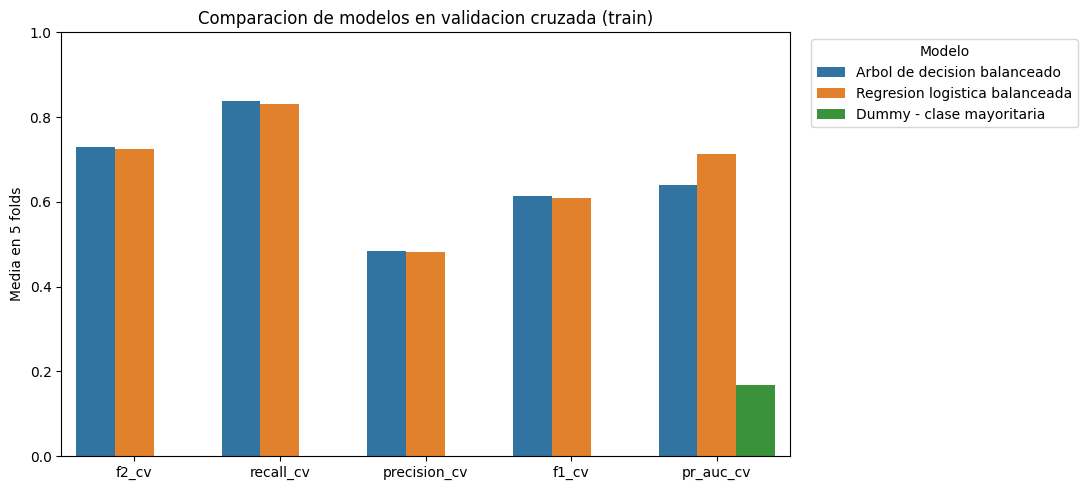

In [12]:
metric_plot = cv_results.melt(
    id_vars="modelo",
    value_vars=["f2_cv", "recall_cv", "precision_cv", "f1_cv", "pr_auc_cv"],
    var_name="metrica",
    value_name="valor",
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=metric_plot,
    x="metrica",
    y="valor",
    hue="modelo",
    ax=ax,
)
ax.set_title("Comparacion de modelos en validacion cruzada (train)")
ax.set_xlabel("")
ax.set_ylabel("Media en 5 folds")
ax.set_ylim(0, 1)
ax.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 9. Matrices de confusion fuera de fold

Para traducir las metricas a cantidades de clientes se generan predicciones **out-of-fold**. Cada cliente de train es predicho por un modelo que no fue entrenado con ese cliente.

Estas matrices todavia no son el resultado final en test, pero permiten entender el costo operativo:

- **verdadero positivo:** cliente con churn correctamente detectado;
- **falso negativo:** cliente que se va y no fue detectado;
- **falso positivo:** alerta sobre un cliente que finalmente no se va;
- **verdadero negativo:** cliente activo correctamente descartado.

,modelo,verdaderos_negativos,falsos_positivos,falsos_negativos,verdaderos_positivos,clientes_contactados,churn_detectado,churn_no_detectado,recall_oof,precision_oof,f2_oof,pr_auc_oof
0,Dummy - clase mayoritaria,3746,0,758,0,0,0,758,0.000,0.000,0.000,0.168
1,Regresion logistica balanceada,3067,679,129,629,1308,629,129,0.830,0.481,0.725,0.710
2,Arbol de decision balanceado,3068,678,123,635,1313,635,123,0.838,0.484,0.731,0.660


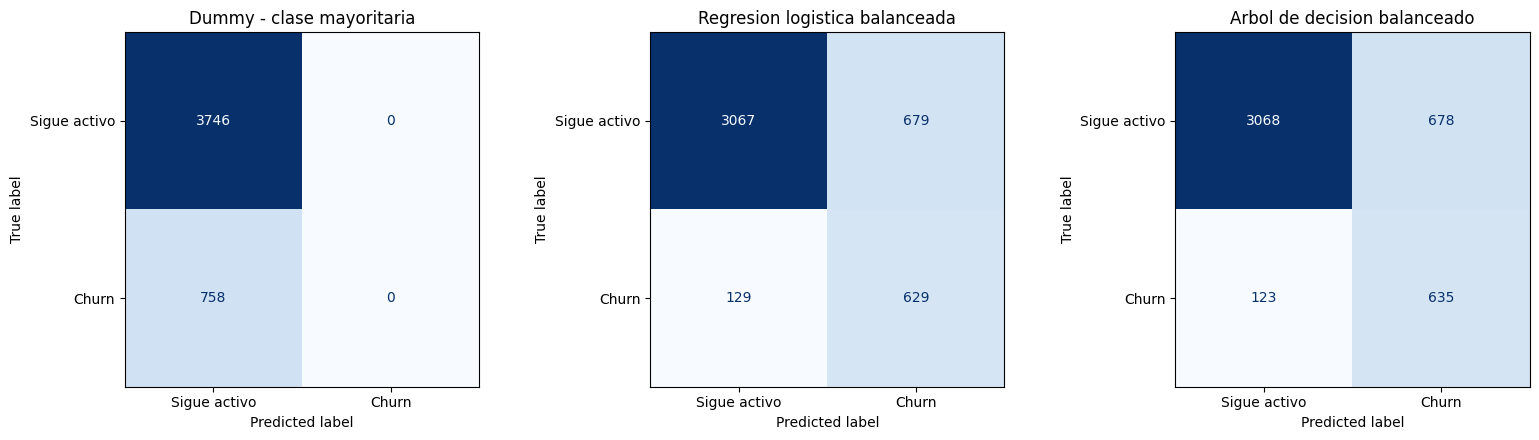

In [13]:
oof_predictions = {}
oof_rows = []

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (model_name, pipeline) in zip(axes, models.items()):
    predictions = cross_val_predict(
        pipeline,
        X_train_model,
        y_train,
        cv=cv,
        method="predict",
        n_jobs=1,
    )
    probabilities = cross_val_predict(
        pipeline,
        X_train_model,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]

    oof_predictions[model_name] = {
        "predictions": predictions,
        "probabilities": probabilities,
    }

    tn, fp, fn, tp = confusion_matrix(y_train, predictions).ravel()
    oof_rows.append({
        "modelo": model_name,
        "verdaderos_negativos": tn,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdaderos_positivos": tp,
        "clientes_contactados": int(fp + tp),
        "churn_detectado": int(tp),
        "churn_no_detectado": int(fn),
        "recall_oof": recall_score(y_train, predictions, zero_division=0),
        "precision_oof": precision_score(y_train, predictions, zero_division=0),
        "f2_oof": fbeta_score(y_train, predictions, beta=2, zero_division=0),
        "pr_auc_oof": average_precision_score(y_train, probabilities),
    })

    ConfusionMatrixDisplay.from_predictions(
        y_train,
        predictions,
        display_labels=["Sigue activo", "Churn"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(model_name)

plt.tight_layout()

oof_summary = pd.DataFrame(oof_rows)
display(oof_summary)

## 10. Interpretacion inicial de los modelos

La comparacion se ordena principalmente por F2 y no debe leerse como una competencia por accuracy:

- El **Dummy** muestra cuanto se obtiene sin detectar churn. Si tiene accuracy alta y recall cero, confirma que accuracy no sirve como criterio principal.
- La **regresion logistica balanceada** aumenta el peso de la clase minoritaria. Suele ofrecer buen recall y coeficientes interpretables, a cambio de generar mas alertas.
- El **arbol balanceado** puede capturar interacciones y reglas no lineales. Se limita su profundidad y se exige un minimo de clientes por hoja para reducir sobreajuste y mantenerlo explicable.

En esta etapa no se declara un ganador definitivo: falta comparar el modelo potente, resolver las variables con riesgo temporal y definir cuantos clientes puede contactar el equipo comercial.

,variable,coeficiente,impacto_absoluto
29,categorical__PreferedOrderCat_Others,1.962,1.962
27,categorical__PreferedOrderCat_Laptop & Accessory,-1.671,1.671
0,numeric_knn__Tenure,-1.184,1.184
28,categorical__PreferedOrderCat_Mobile Phone,-0.805,0.805
6,numeric_knn__Complain,0.715,0.715
10,numeric_knn__CashbackAmount,-0.694,0.694
5,numeric_knn__NumberOfAddress,0.636,0.636
11,numeric_knn__OrdersPerTenure,0.564,0.564
32,categorical__MaritalStatus_Single,0.505,0.505
9,numeric_knn__DaySinceLastOrder,-0.484,0.484


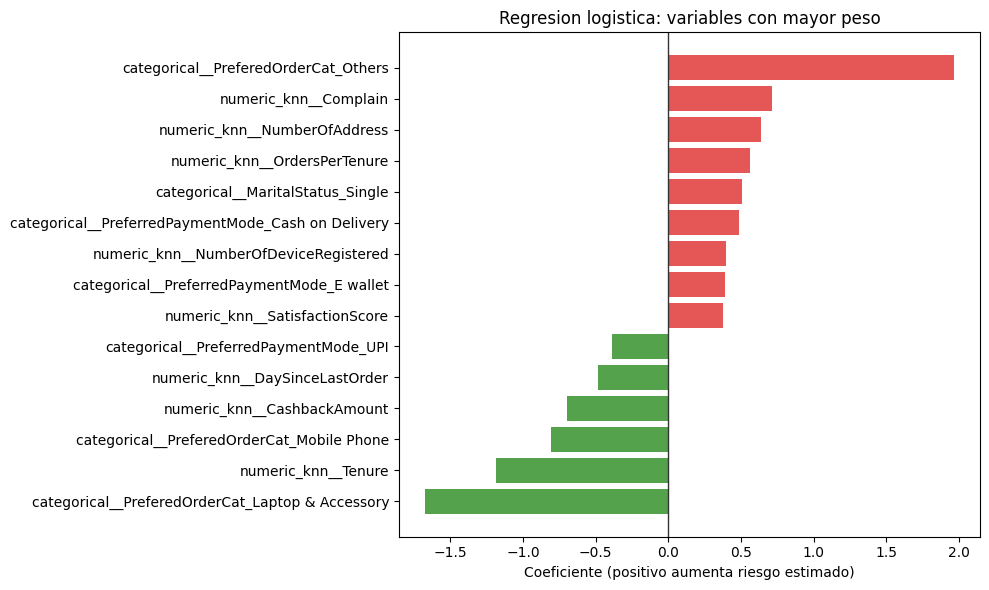

In [14]:
fitted_models = {}
for model_name, pipeline in models.items():
    fitted_models[model_name] = pipeline.fit(X_train_model, y_train)

feature_names_logistic = fitted_models["Regresion logistica balanceada"][
    "preprocessor"
].get_feature_names_out()
logistic_coefficients = fitted_models["Regresion logistica balanceada"][
    "model"
].coef_[0]

logistic_importance = pd.DataFrame({
    "variable": feature_names_logistic,
    "coeficiente": logistic_coefficients,
})
logistic_importance["impacto_absoluto"] = logistic_importance["coeficiente"].abs()
logistic_top = logistic_importance.nlargest(15, "impacto_absoluto").sort_values("coeficiente")

fig, ax = plt.subplots(figsize=(10, 6))
colors = np.where(logistic_top["coeficiente"] > 0, "#E45756", "#54A24B")
ax.barh(logistic_top["variable"], logistic_top["coeficiente"], color=colors)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Regresion logistica: variables con mayor peso")
ax.set_xlabel("Coeficiente (positivo aumenta riesgo estimado)")
ax.set_ylabel("")
plt.tight_layout()

display(logistic_top.sort_values("impacto_absoluto", ascending=False))

,variable,importancia
0,numeric_knn__Tenure,0.611
6,numeric_knn__Complain,0.100
11,numeric_knn__OrdersPerTenure,0.086
28,categorical__PreferedOrderCat_Mobile Phone,0.042
1,numeric_knn__CityTier,0.034
32,categorical__MaritalStatus_Single,0.030
5,numeric_knn__NumberOfAddress,0.026
4,numeric_knn__SatisfactionScore,0.022
3,numeric_knn__NumberOfDeviceRegistered,0.018
8,numeric_knn__OrderCount,0.017


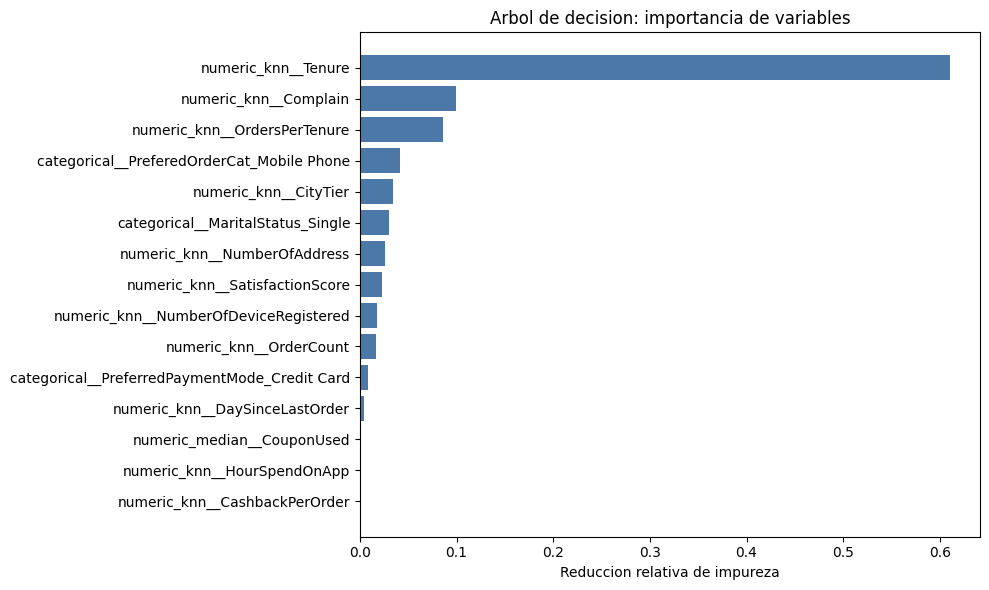

In [15]:
tree_pipeline = fitted_models["Arbol de decision balanceado"]
feature_names_tree = tree_pipeline["preprocessor"].get_feature_names_out()
tree_importances = pd.DataFrame({
    "variable": feature_names_tree,
    "importancia": tree_pipeline["model"].feature_importances_,
}).sort_values("importancia", ascending=False)

tree_top = tree_importances.head(15).sort_values("importancia")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(tree_top["variable"], tree_top["importancia"], color="#4C78A8")
ax.set_title("Arbol de decision: importancia de variables")
ax.set_xlabel("Reduccion relativa de impureza")
ax.set_ylabel("")
plt.tight_layout()

display(tree_importances.head(15))

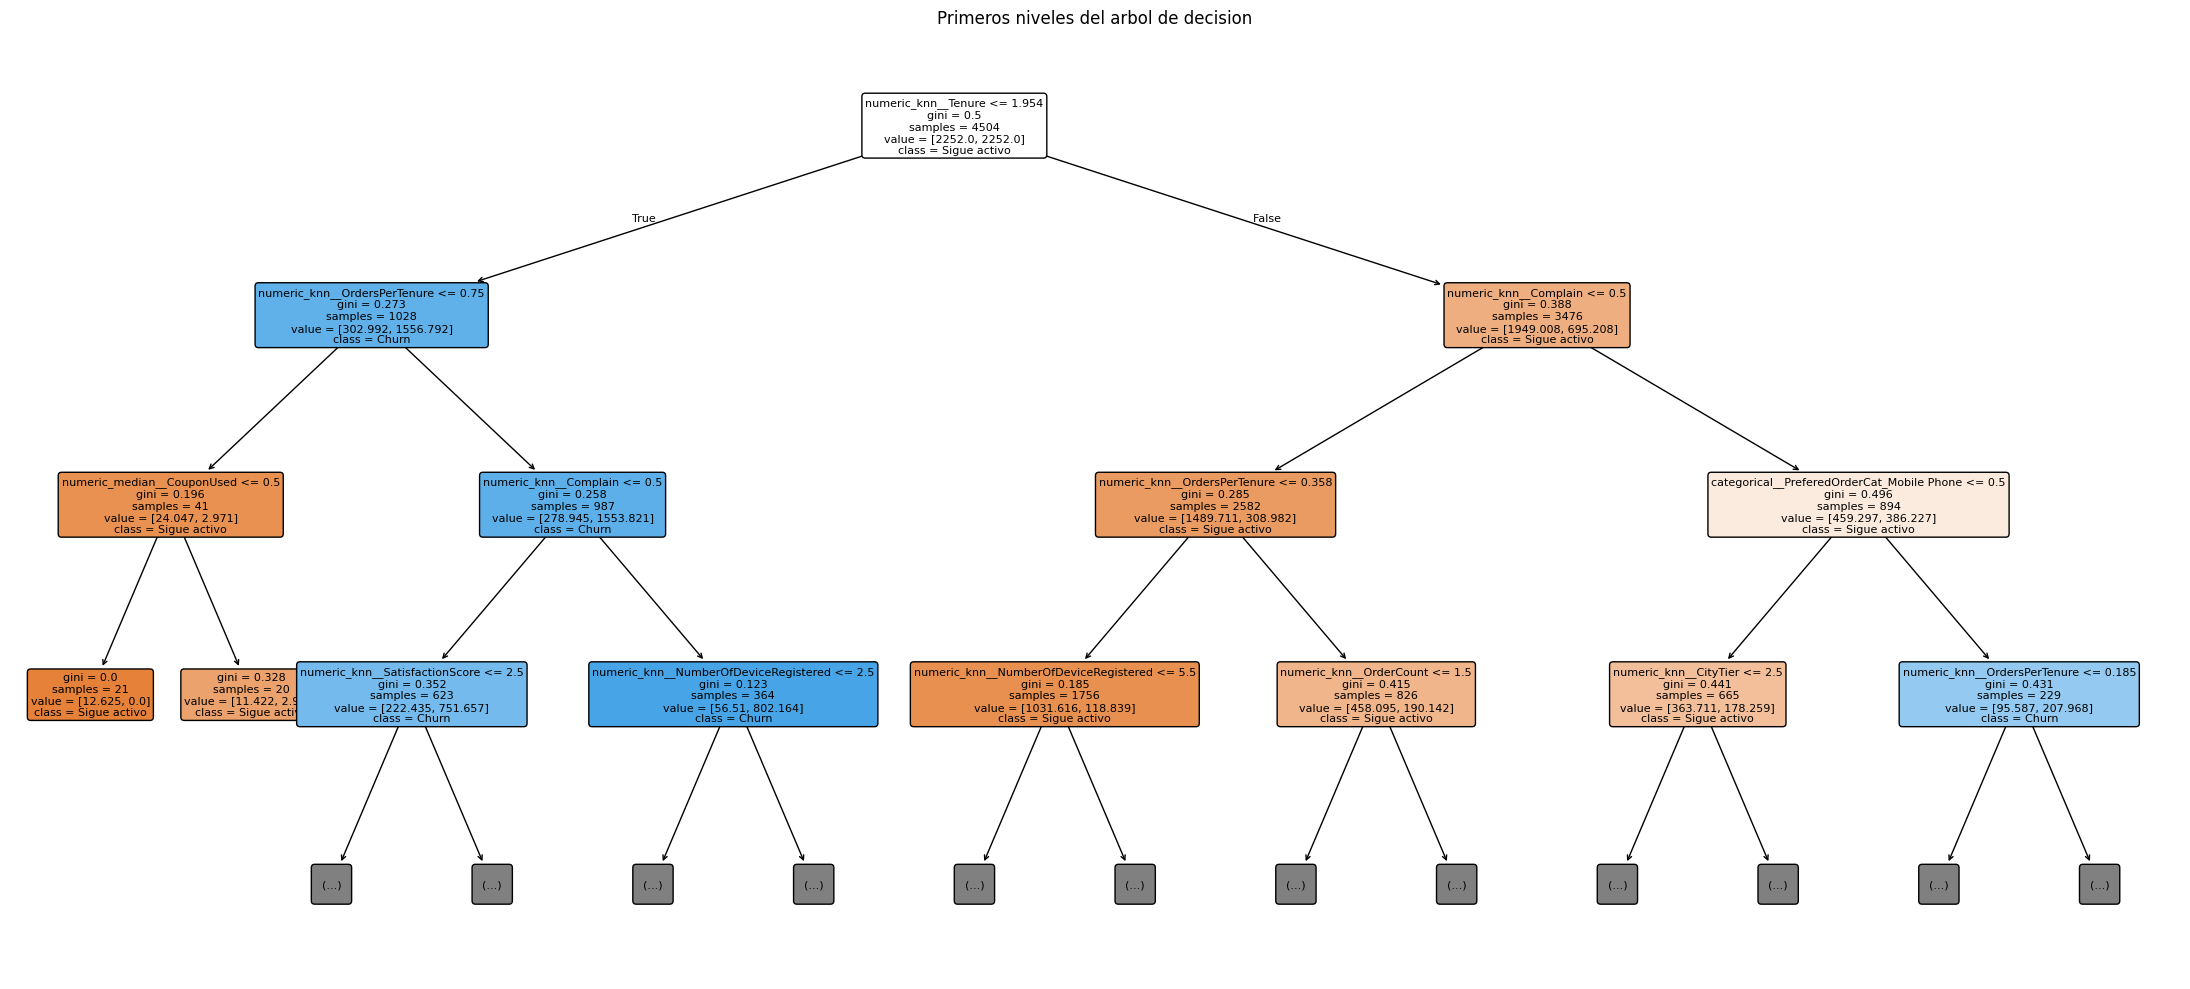

In [16]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    tree_pipeline["model"],
    feature_names=feature_names_tree,
    class_names=["Sigue activo", "Churn"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
ax.set_title("Primeros niveles del arbol de decision")
plt.tight_layout()

## 11. Como leer las explicaciones

**Regresion logistica**

- Un coeficiente positivo aumenta el riesgo estimado de churn.
- Un coeficiente negativo reduce ese riesgo estimado.
- El tamano del coeficiente permite comparar peso dentro del modelo porque las variables numericas fueron estandarizadas.

**Arbol de decision**

- La importancia indica cuanto ayudo una variable a separar clases dentro del arbol.
- Los primeros niveles muestran las reglas que afectan a mas clientes.
- Ni coeficientes ni importancias prueban causalidad. Describen como decide el modelo con estos datos.

Las categorias demograficas deben interpretarse con especial cautela: pueden ayudar a describir segmentos, pero no deberian convertirse por si solas en reglas de trato diferencial.

In [17]:
dummy_row = cv_results.loc[cv_results["modelo"] == "Dummy - clase mayoritaria"].iloc[0]
logistic_row = cv_results.loc[cv_results["modelo"] == "Regresion logistica balanceada"].iloc[0]
tree_row = cv_results.loc[cv_results["modelo"] == "Arbol de decision balanceado"].iloc[0]

print("Lectura automatica de validacion cruzada")
print("-" * 45)
print(
    f"Dummy: accuracy={dummy_row['accuracy_cv']:.3f}, "
    f"recall={dummy_row['recall_cv']:.3f}, "
    f"F2={dummy_row['f2_cv']:.3f}."
)
print(
    f"Logistica: recall={logistic_row['recall_cv']:.3f}, "
    f"precision={logistic_row['precision_cv']:.3f}, "
    f"F2={logistic_row['f2_cv']:.3f}, "
    f"PR-AUC={logistic_row['pr_auc_cv']:.3f}."
)
print(
    f"Arbol: recall={tree_row['recall_cv']:.3f}, "
    f"precision={tree_row['precision_cv']:.3f}, "
    f"F2={tree_row['f2_cv']:.3f}, "
    f"PR-AUC={tree_row['pr_auc_cv']:.3f}."
)
print(
    f"Gap F2 train-CV del arbol: "
    f"{tree_row['f2_train'] - tree_row['f2_cv']:.3f}."
)
print("El conjunto de test no fue utilizado.")

Lectura automatica de validacion cruzada
---------------------------------------------
Dummy: accuracy=0.832, recall=0.000, F2=0.000.
Logistica: recall=0.830, precision=0.481, F2=0.724, PR-AUC=0.712.
Arbol: recall=0.838, precision=0.484, F2=0.730, PR-AUC=0.641.
Gap F2 train-CV del arbol: 0.023.
El conjunto de test no fue utilizado.


## 12. Ajuste del umbral sin tocar test

El umbral estandar de 0,50 no tiene por que ser el mejor para el negocio. Se evaluan umbrales entre 0,20 y 0,80 usando exclusivamente probabilidades fuera de fold de train.

Para cada umbral se calcula:

- F2, metrica principal;
- recall y precision;
- cantidad de clientes que recibirian una alerta;
- churn detectado y no detectado;
- falsas alertas.

El umbral provisorio de cada modelo es el que maximiza F2. Esta optimizacion no usa test y no constituye todavia una decision operativa final: el umbral tambien debe respetar presupuesto y capacidad de contacto.

In [18]:
thresholds = np.round(np.arange(0.20, 0.81, 0.01), 2)
threshold_rows = []

candidate_models = [
    "Regresion logistica balanceada",
    "Arbol de decision balanceado",
]

for model_name in candidate_models:
    probabilities = oof_predictions[model_name]["probabilities"]

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_train, predictions).ravel()

        threshold_rows.append({
            "modelo": model_name,
            "umbral": threshold,
            "f2": fbeta_score(y_train, predictions, beta=2, zero_division=0),
            "recall": recall_score(y_train, predictions, zero_division=0),
            "precision": precision_score(y_train, predictions, zero_division=0),
            "clientes_contactados": int(tp + fp),
            "churn_detectado": int(tp),
            "churn_no_detectado": int(fn),
            "falsas_alertas": int(fp),
        })

threshold_results = pd.DataFrame(threshold_rows)

best_thresholds = (
    threshold_results
    .sort_values(
        ["modelo", "f2", "precision", "umbral"],
        ascending=[True, False, False, False],
    )
    .groupby("modelo", as_index=False)
    .first()
    .sort_values("f2", ascending=False)
)

display(best_thresholds.round({
    "umbral": 2,
    "f2": 3,
    "recall": 3,
    "precision": 3,
}))


,modelo,umbral,f2,recall,precision,clientes_contactados,churn_detectado,churn_no_detectado,falsas_alertas
0,Arbol de decision balanceado,0.520,0.731,0.838,0.484,1313,635,123,678
1,Regresion logistica balanceada,0.470,0.727,0.847,0.464,1383,642,116,741


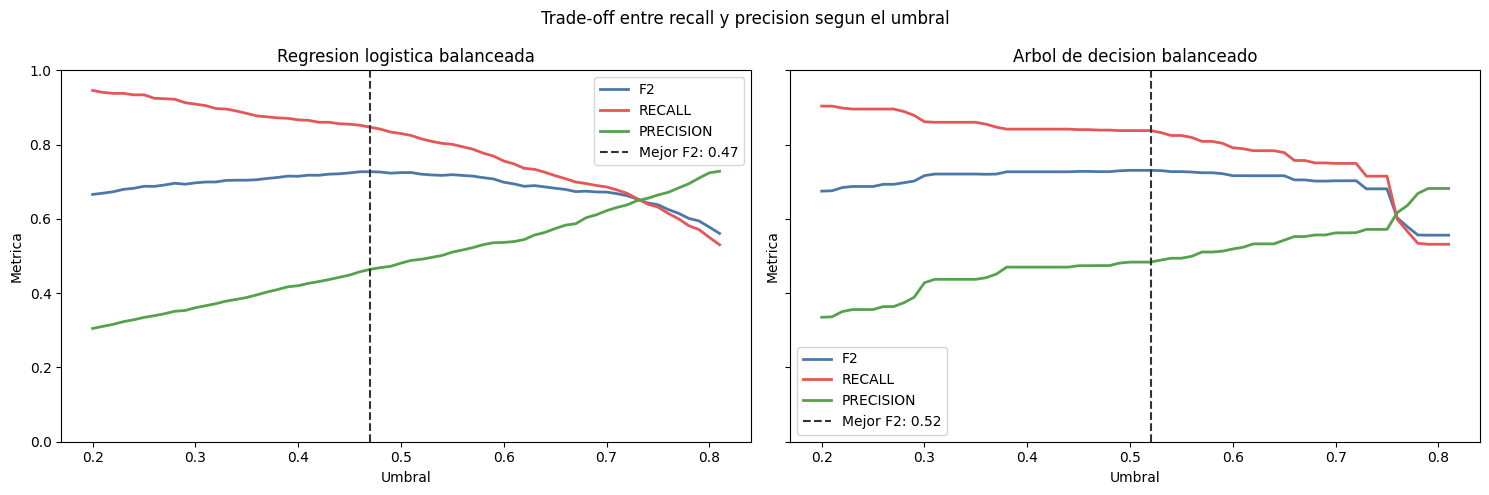

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, model_name in zip(axes, candidate_models):
    model_thresholds = threshold_results[threshold_results["modelo"] == model_name]
    best_row = best_thresholds[best_thresholds["modelo"] == model_name].iloc[0]

    for metric, color in [
        ("f2", "#4C78A8"),
        ("recall", "#E45756"),
        ("precision", "#54A24B"),
    ]:
        ax.plot(
            model_thresholds["umbral"],
            model_thresholds[metric],
            label=metric.upper(),
            color=color,
            linewidth=2,
        )

    ax.axvline(
        best_row["umbral"],
        color="#333333",
        linestyle="--",
        label=f"Mejor F2: {best_row['umbral']:.2f}",
    )
    ax.set_title(model_name)
    ax.set_xlabel("Umbral")
    ax.set_ylabel("Metrica")
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle("Trade-off entre recall y precision segun el umbral")
plt.tight_layout()


In [20]:
reference_thresholds = []

for model_name in candidate_models:
    model_thresholds = threshold_results[threshold_results["modelo"] == model_name]
    best_threshold = best_thresholds.loc[
        best_thresholds["modelo"] == model_name, "umbral"
    ].iloc[0]

    selected = model_thresholds[
        model_thresholds["umbral"].isin(
            sorted(set([0.40, 0.50, 0.60, float(best_threshold)]))
        )
    ].copy()
    reference_thresholds.append(selected)

threshold_comparison = (
    pd.concat(reference_thresholds, ignore_index=True)
    .sort_values(["modelo", "umbral"])
)

display(threshold_comparison.round({
    "umbral": 2,
    "f2": 3,
    "recall": 3,
    "precision": 3,
}))


,modelo,umbral,f2,recall,precision,clientes_contactados,churn_detectado,churn_no_detectado,falsas_alertas
4,Arbol de decision balanceado,0.400,0.727,0.842,0.470,1357,638,120,719
5,Arbol de decision balanceado,0.500,0.731,0.838,0.484,1313,635,123,678
6,Arbol de decision balanceado,0.520,0.731,0.838,0.484,1313,635,123,678
7,Arbol de decision balanceado,0.600,0.716,0.792,0.519,1156,600,158,556
0,Regresion logistica balanceada,0.400,0.715,0.867,0.420,1564,657,101,907
1,Regresion logistica balanceada,0.470,0.727,0.847,0.464,1383,642,116,741
2,Regresion logistica balanceada,0.500,0.725,0.830,0.481,1308,629,129,679
3,Regresion logistica balanceada,0.600,0.699,0.756,0.537,1068,573,185,495


### Resultado del ajuste

**Regresion logistica**

- El mejor F2 aparece con umbral `0,47`.
- Recall sube de 83,0% a 84,7%, pero precision baja de 48,1% a 46,4%.
- Se contactarian 1.383 clientes en lugar de 1.308: 75 contactos adicionales.
- Se detectan 642 churns en lugar de 629: trece casos mas.

**Arbol de decision**

- El maximo F2 se mantiene practicamente igual alrededor de `0,50-0,52`.
- Esto indica que el umbral estandar ya esta cerca del mejor equilibrio F2 para este arbol.
- Un umbral `0,60` puede considerarse como alternativa operativa: precision sube a 51,9% y se reducen 157 contactos, pero recall baja a 79,2% y se pierden 35 churns adicionales.

### Como interpretar la decision

- Bajar el umbral genera mas alertas: normalmente sube recall y baja precision.
- Subirlo reduce contactos y falsas alertas: normalmente mejora precision, pero deja escapar mas churns.
- El maximo F2 es un equilibrio matematico coherente con la prioridad definida, no una orden automatica para negocio.

Por ahora se conserva `0,52` como umbral F2 provisorio del arbol. `0,60` queda documentado como opcion si el equipo necesita reducir volumen de contactos. La decision final requiere conocer capacidad y costo comercial.

## 13. Conclusiones provisorias y mejoras necesarias

### Resultados principales

1. El **Dummy** alcanza cerca de 83% de accuracy porque siempre predice que el cliente sigue activo, pero su recall y F2 son 0. No detecta ninguno de los clientes que churnean y no tiene utilidad comercial.
2. La **regresion logistica balanceada** logra aproximadamente 83,0% de recall y 48,1% de precision. En las predicciones fuera de fold detecta 629 de 758 churns y genera 679 falsas alertas.
3. El **arbol de decision balanceado** logra alrededor de 83,8% de recall y 48,4% de precision. Detecta 635 churns y genera 678 falsas alertas.
4. **F2 es el criterio principal:** favorece detectar churn, pero tambien recompensa al arbol por reducir falsas alertas. La comparacion exacta se muestra en la tabla ejecutada.
5. La **regresion logistica obtiene mejor PR-AUC**. Esto indica que ordena mejor a los clientes desde mayor a menor riesgo y puede resultar mas util si luego se define un umbral segun presupuesto.
6. El arbol presenta una brecha F2 train-CV de 2,3 puntos porcentuales. Con la profundidad limitada no aparece una senal fuerte de sobreajuste.
7. El feature engineering mejora F2 de 0,704 a 0,724 en la logistica y de 0,718 a 0,730 en el arbol. En el arbol aumenta recall, pero reduce precision y PR-AUC, por lo que la mejora no es gratuita.
8. El ajuste de la logistica a `0,47` aumenta recall y detecta trece churns mas, pero exige 75 contactos adicionales. En el arbol, `0,50-0,52` ya esta cerca del maximo F2.
9. `Tenure` domina claramente el arbol. La nueva variable `OrdersPerTenure` aparece tercera en importancia, detras de `Tenure` y `Complain`; las razones de cashback y cupones tienen poco peso individual en este arbol.

### Lectura de negocio

Con el umbral estandar, ambos modelos detectan aproximadamente 8 de cada 10 clientes que se van. La diferencia esta en el costo operativo:

- el arbol detecta seis churns adicionales frente a la logistica y genera una falsa alerta menos;
- ambos modelos requieren contactar cerca de 1.300 clientes con el umbral estandar;
- F2 permite resumir este intercambio dando prioridad a no perder churns sin tratar las falsas alertas como gratuitas.

No se declara un ganador definitivo. El F2 mas alto sera el punto de partida, pero tambien faltan Random Forest, la revision de temporalidad y la definicion de capacidad comercial.

### Cuidados al interpretar variables

Los coeficientes logisticos son efectos condicionales: describen el aporte de una variable manteniendo las demas constantes. Por eso una categoria puede mostrar un signo distinto al observado en una tabla simple del EDA. No es una contradiccion automatica ni prueba causalidad.

### Mejoras para la siguiente iteracion

1. Comparar Random Forest con los mismos folds, usando F2 como criterio principal.
2. Repetir la evaluacion sin `Complain` y `DaySinceLastOrder` si no se confirma su temporalidad.
3. Validar el umbral elegido contra capacidad y costo real de contacto.
4. Revisar estabilidad y resultados por subgrupos para evitar reglas comerciales injustas.
5. Evaluar test una sola vez despues de cerrar modelo, variables y umbral.
6. Generar SHAP global y local solamente para el modelo final.

In [21]:
assert set(models) == {
    "Dummy - clase mayoritaria",
    "Regresion logistica balanceada",
    "Arbol de decision balanceado",
}
assert len(cv_results) == 3
assert cv_results[["f2_cv", "recall_cv", "precision_cv", "f1_cv", "pr_auc_cv"]].notna().all().all()
assert len(best_thresholds) == 2
assert best_thresholds['f2'].between(0, 1).all()
assert set(ENGINEERED_FEATURES).issubset(X_train_model.columns)
assert set(ENGINEERED_FEATURES).issubset(X_test_model.columns)
assert X_train_model[ENGINEERED_FEATURES].replace([np.inf, -np.inf], np.nan).notna().sum().sum() > 0
assert not np.isinf(X_train_model[ENGINEERED_FEATURES].to_numpy(dtype=float)).any()
assert not np.isinf(X_test_model[ENGINEERED_FEATURES].to_numpy(dtype=float)).any()
assert (feature_engineering_comparison.loc[
    feature_engineering_comparison["modelo"] != "Dummy - clase mayoritaria", "delta_f2"
] > 0).all()
assert X_test_model.index.equals(X_test.index)
assert y_test.equals(y.loc[X_test.index])

print("Validaciones de modelado OK")
print("Modelos comparados: Dummy, regresion logistica y arbol de decision")
print("Metrica principal: F2 (beta=2)")
print("CV: StratifiedKFold con 5 folds")
print("Feature engineering validado:", ENGINEERED_FEATURES)
print("Test permanece reservado:", len(X_test_model), "clientes")

Validaciones de modelado OK
Modelos comparados: Dummy, regresion logistica y arbol de decision
Metrica principal: F2 (beta=2)
CV: StratifiedKFold con 5 folds
Feature engineering validado: ['OrdersPerTenure', 'CashbackPerOrder', 'CouponsPerOrder']
Test permanece reservado: 1126 clientes
